In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("Default.csv")


In [3]:
df.head()

,default,student,balance,income
0,No,No,729.526495,44361.62507
1,No,Yes,817.180407,12106.13470
2,No,No,1073.549164,31767.13895
3,No,No,529.250605,35704.49394
4,No,No,785.655883,38463.49588


In [4]:
df.shape

(10000, 4)

In [5]:
df.isna().sum()

default    0
student    0
balance    0
income     0
dtype: int64

In [6]:
import matplotlib.pyplot as plt


In [7]:
df["student"].value_counts()

student
No     7056
Yes    2944
Name: count, dtype: int64

In [8]:
df["default"].value_counts()

default
No     9667
Yes     333
Name: count, dtype: int64

In [9]:
df["student"].unique()

array(['No', 'Yes'], dtype=object)

{'whiskers': [<matplotlib.lines.Line2D at 0x1a60403f750>,
 'caps': [<matplotlib.lines.Line2D at 0x1a60410e0d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1a60403dd10>],
 'medians': [<matplotlib.lines.Line2D at 0x1a60410e350>],
 'fliers': [<matplotlib.lines.Line2D at 0x1a60410e490>],
 'means': []}

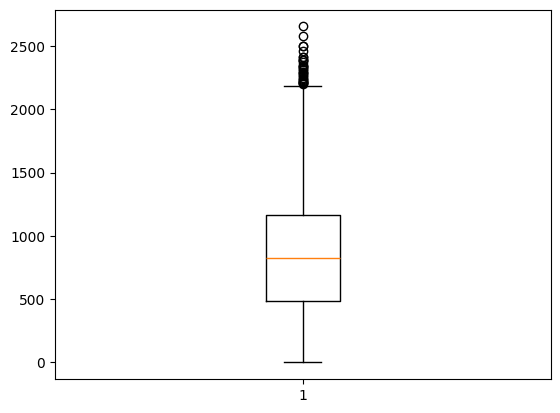

In [10]:
plt.boxplot(df["balance"])

In [11]:
mean = df["balance"].mean()
std=df["balance"].std()

In [12]:
import seaborn as sns

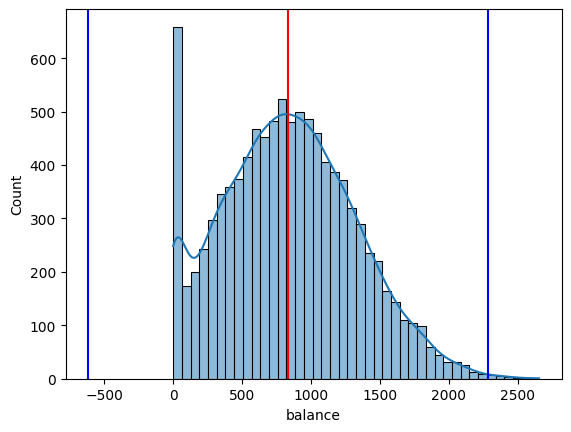

In [13]:
sns.histplot(data=df , x="balance" ,kde=True)
plt.axvline(mean , color="red")
plt.axvline(mean+3*std , color = "blue")
plt.axvline(mean-3*std,color="blue")

In [14]:
df[df["balance"] > (mean*3+std)]

,default,student,balance,income


In [15]:
mean*3+std

np.float64(2989.8396420551626)

In [16]:
df.drop(df[df["balance"]>mean+(3*std)].index , inplace=True)

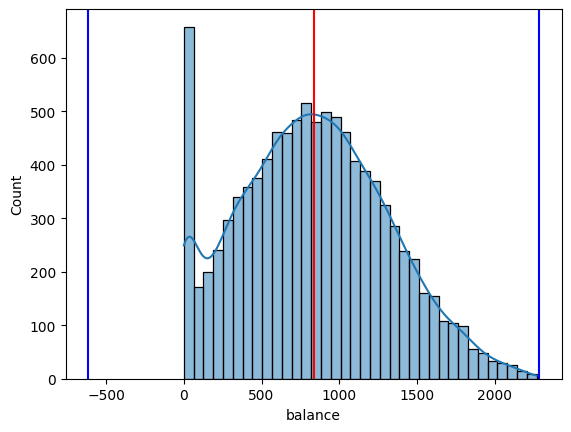

In [17]:
sns.histplot(data=df , x="balance" ,kde=True)
plt.axvline(mean , color="red")
plt.axvline(mean+3*std , color = "blue")
plt.axvline(mean-3*std,color="blue")

In [18]:
# corrr = df["default"].corr(df["student"])
# 

In [19]:
# df = pd.get_dummies(df,columns=["student"],dtype="int")

In [20]:
df.head()

,default,student,balance,income
0,No,No,729.526495,44361.62507
1,No,Yes,817.180407,12106.13470
2,No,No,1073.549164,31767.13895
3,No,No,529.250605,35704.49394
4,No,No,785.655883,38463.49588


In [21]:
# df=pd.get_dummies(df,columns=["default"],dtype = "int")

In [22]:
df.head()

,default,student,balance,income
0,No,No,729.526495,44361.62507
1,No,Yes,817.180407,12106.13470
2,No,No,1073.549164,31767.13895
3,No,No,529.250605,35704.49394
4,No,No,785.655883,38463.49588


In [23]:
# sns.heatmap(df.corr() ,annot=True)

In [24]:
df.drop("student",axis=1,inplace=True)

In [25]:
df.head()

,default,balance,income
0,No,729.526495,44361.62507
1,No,817.180407,12106.13470
2,No,1073.549164,31767.13895
3,No,529.250605,35704.49394
4,No,785.655883,38463.49588


In [26]:
df.describe()

,balance,income
count,9980.000000,9980.000000
mean,832.247137,33530.953295
std,479.101692,13331.877798
min,0.000000,771.967729
25%,481.127011,21357.458397
50%,821.496224,34562.497710
75%,1164.542737,43810.685280
max,2269.946966,73554.233500


In [27]:
x = df.drop("default",axis = 1)
y=df["default"]


In [28]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
x_ss = ss.fit_transform(x)

In [29]:
df.describe()

,balance,income
count,9980.000000,9980.000000
mean,832.247137,33530.953295
std,479.101692,13331.877798
min,0.000000,771.967729
25%,481.127011,21357.458397
50%,821.496224,34562.497710
75%,1164.542737,43810.685280
max,2269.946966,73554.233500


In [30]:
pd.DataFrame(x_ss)

,0,1
0,-0.214413,0.812430
1,-0.031449,-1.607117
2,0.503680,-0.132307
3,-0.632458,0.163042
4,-0.097252,0.370000
...,...,...
9975,-0.251926,1.459839
9976,-0.155057,-1.040433
9977,0.027480,1.883190
9978,1.537876,0.235399


In [31]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x_ss , y,test_size=0.2 , random_state=20)

In [32]:
from sklearn.neighbors import KNeighborsClassifier 
model = KNeighborsClassifier(n_neighbors= 3)


In [33]:
model.fit(x_train , y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [34]:
test_pred = model.predict(x_test)


In [35]:
from sklearn.metrics import accuracy_score , confusion_matrix 
accuracy_score(y_test ,test_pred)


0.9679358717434869

In [36]:
y_test.shape

(1996,)

In [37]:
y_test.value_counts()

default
No     1935
Yes      61
Name: count, dtype: int64

In [38]:
res = confusion_matrix(y_test , test_pred )

In [39]:
pd.DataFrame(res , columns=["pred +ve " , "pred - ve"] , index=["actual +ve" , "actual -ve"])

,pred +ve,pred - ve
actual +ve,1912,23
actual -ve,41,20


decide k 

In [40]:
train_acc= []
test_acc = []
k_values = []
for i in range(3,16,2):
    k_values.append(i)
    knn = KNeighborsClassifier(n_neighbors= i )
    knn.fit(x_train , y_train)
    train_pred = knn.predict(x_train)
    test_pred = knn.predict(x_test)
    train_acc.append(accuracy_score(y_train , train_pred ))
    test_acc.append(accuracy_score(y_test , test_pred))

In [41]:
train_acc

[0.9770791583166333,
 0.9752004008016032,
 0.9739478957915831,
 0.9748246492985972,
 0.9743236472945892,
 0.9734468937875751,
 0.9736973947895792]

In [42]:
test_acc

[0.9679358717434869,
 0.9709418837675351,
 0.9744488977955912,
 0.9754509018036072,
 0.9759519038076152,
 0.9764529058116233,
 0.9764529058116233]

In [43]:
import matplotlib.pyplot as plt 


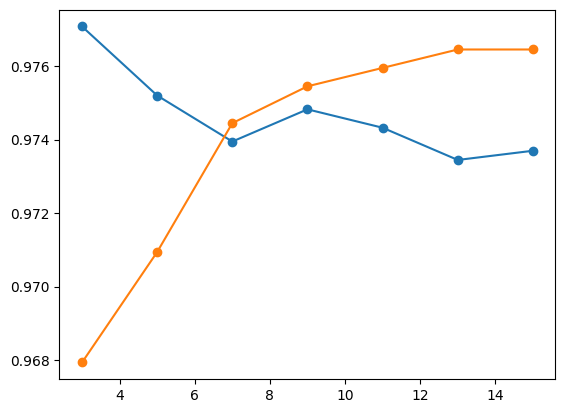

In [44]:
plt.plot(k_values ,train_acc ,marker ="o" )
plt.plot(k_values ,test_acc , marker = "o")